# Redes neuronales como aproximadores numéricos
#### para pricing de opciones bajo Black-Scholes y Heston

**Ángel Fernández Sánchez · Jorge Alfageme Sotillos · Héctor Pérez Ledesma**
*Métodos numéricos · Curso 2025/2026*

---

Este notebook acompaña al trabajo y reproduce, **a escala reducida y con el propio código del repositorio** (`src/`), sus piezas centrales. La idea de fondo es usar una red neuronal no como un sistema que aprende del mercado, sino como un **aproximador funcional** que imita a un solver de pricing ya conocido. Se entrena *offline* con datos sintéticos generados por el propio modelo y, una vez entrenada, sustituye al solver en tareas que exigen millones de evaluaciones —calibración diaria, Greeks, Montecarlo— siendo órdenes de magnitud más rápida y, además, diferenciable por construcción.

Conforme los modelos ganan realismo se vuelven más caros de evaluar. Lo que en Black-Scholes es una fórmula cerrada, en Heston es una integral que hay que resolver por Fourier. Por eso usamos **Black-Scholes como caso de validación** —conocemos la solución exacta y podemos medir errores de precio, Delta y volatilidad implícita— y **Heston como caso principal**, donde el surrogate empieza a tener sentido práctico.

> **Pregunta de investigación.** ¿Bajo qué condiciones una red neuronal profunda puede actuar como un surrogate preciso, rápido y diferenciable para funciones de pricing de opciones?

El estudio se articula en **seis experimentos**, cada uno atacando una perspectiva distinta de la pregunta —métrica de evaluación, activación de la red, distribución del muestreo, eficiencia computacional, información diferencial en la pérdida y profundidad junto al scheduler de learning rate— sobre **catorce surrogates**. El notebook recorre primero el método a pequeña escala, entrenando un surrogate en vivo, y después evalúa las redes reales del trabajo sobre un test reducido. El código completo está en [github.com/hectoorperezz/proyecto-final-metodos-numericos](https://github.com/hectoorperezz/proyecto-final-metodos-numericos).

---

## 0. Preparación del entorno

Fijamos la raíz del repositorio en el `path`, importamos desde `src/` y dejamos una semilla global para que el notebook sea determinista.

In [1]:
import sys, os
from pathlib import Path

# Localiza la raíz del repo (la carpeta que contiene 'src/').
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.utils import set_global_seed
from src.solvers import BlackScholesSolver, HestonSolver
from src.datasets import (
    make_black_scholes_domain, make_heston_domain,
    UniformSampler, FocusedSampler, DatasetGenerator,
)
from src.models import MLP, ACTIVATIONS, surrogate_price_and_delta
from src.training import Trainer, PriceLoss

set_global_seed(42)

# Paleta para la primera mitad (demo). La sección de resultados aplica paper_style.
UNIYELLOW, UNIBLACK, GOLD = "#FFD100", "#1A1A1A", "#8A6D00"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.edgecolor": UNIBLACK,
    "axes.linewidth": 0.8, "axes.grid": True, "grid.alpha": 0.25,
})

print("Entorno listo. Raíz:", ROOT)
print("Torch", torch.__version__, "| dispositivo: CPU")

/Users/hectorperezledesma/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Entorno listo. Raíz: /Users/hectorperezledesma/Desktop/Universidad/Master/Python/proyecto-final-metodos-numericos
Torch 2.2.2 | dispositivo: CPU


---

## 1. Casos de estudio: Black-Scholes y Heston

El trabajo se articula sobre dos modelos. **Black-Scholes** opera como caso de validación. No necesita surrogate —la fórmula cerrada ya es muy rápida—, pero por eso mismo es el entorno de prueba ideal, porque conocemos la solución exacta, la Delta analítica y la inversión a volatilidad implícita. El subyacente sigue un movimiento browniano geométrico con volatilidad $\sigma$ constante,

$$dS_t = (r-q)\,S_t\,dt + \sigma\,S_t\,dW_t,$$

y la call europea tiene precio cerrado

$$C = S\,e^{-qT}N(d_1) - K\,e^{-rT}N(d_2), \qquad d_{1,2} = \frac{\ln(S/K) + (r-q \pm \tfrac12\sigma^2)T}{\sigma\sqrt{T}},$$

con Delta $\Delta = e^{-qT}N(d_1)$. Sus entradas son $m=S/K$, $T$, $r$ y $\sigma$.

**Heston** es el caso principal, donde el surrogate ya tiene sentido. Añade volatilidad estocástica, la varianza $v_t$ revierte a la media y se correlaciona con el subyacente,

$$dS_t = (r-q)S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^{S}, \qquad dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^{v}, \qquad dW_t^{S}dW_t^{v} = \rho\,dt.$$

El precio se obtiene por Fourier semi-cerrada, $C = Se^{-qT}P_1 - Ke^{-rT}P_2$, con $\Delta = e^{-qT}P_1$. Los cinco parámetros $\kappa,\theta,\xi,\rho,v_0$ entran en la red junto con $m$, $T$ y $r$, de modo que **una sola red cubre todas las parametrizaciones** del modelo.

La celda siguiente valida el solver de Black-Scholes en un punto y dibuja la curva de precio frente a moneyness en ambos modelos con `src.solvers`.

BS  precio: 0.08916 | Delta: 0.57926 | Vega: 0.391043


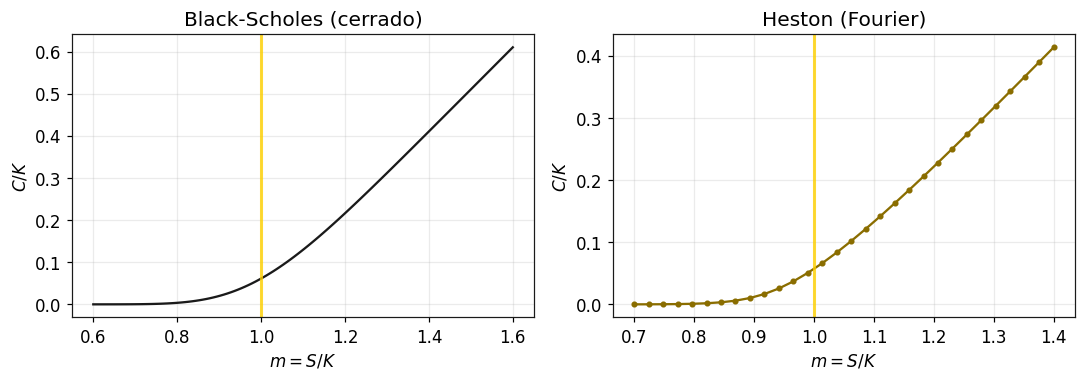

In [2]:
bs = BlackScholesSolver()
hes = HestonSolver()

# Sanity de Black-Scholes en un punto at-the-money.
S, K, T, r, sigma = 1.0, 1.0, 1.0, 0.02, 0.20
print("BS  precio:", round(bs.call_price(S, K, T, r, sigma), 6),
      "| Delta:", round(bs.call_delta(S, K, T, r, sigma), 6),
      "| Vega:", round(bs.call_vega(S, K, T, r, sigma), 6))

# Curva de precio frente a moneyness (K=1, así que m = S).
m = np.linspace(0.6, 1.6, 120)
bs_curve = bs.call_price(m, 1.0, 0.5, 0.02, 0.20)
# Heston: misma rejilla pero menos puntos (Fourier es más caro).
m_h = np.linspace(0.7, 1.4, 30)
hes_curve = hes.call_price(m_h, 1.0, 0.5, 0.02, v0=0.04, theta=0.04, kappa=1.5, xi=0.5, rho=-0.6)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(m, bs_curve, color=UNIBLACK); ax[0].set_title("Black-Scholes (cerrado)")
ax[1].plot(m_h, hes_curve, color=GOLD, marker="o", ms=3); ax[1].set_title("Heston (Fourier)")
for a in ax:
    a.axvline(1.0, color=UNIYELLOW, lw=2, alpha=0.8); a.set_xlabel("$m = S/K$"); a.set_ylabel("$C/K$")
plt.tight_layout(); plt.show()

---

## 2. Targets, normalización y métricas

El target es el precio normalizado por strike, $y = C/K$, y el input financiero principal es la moneyness $m = S/K$. Esto elimina una escala redundante —si spot y strike se multiplican por la misma constante, el precio escala con el strike— y facilita la Delta,

$$\Delta = \frac{\partial C}{\partial S} = \frac{\partial (C/K)}{\partial (S/K)} = \frac{\partial y}{\partial m}.$$

Fijamos $q = 0$ en todos los experimentos. Además, todos los inputs se normalizan a $[0,1]$ por min-max antes de entrar en la red, lo que mejora el condicionamiento del optimizador sin cambiar el problema. Como la red ve $m_{\text{norm}}$, la Delta vuelve a la escala financiera por la regla de la cadena,

$$\hat{\Delta} = \frac{\partial \hat{y}}{\partial m} = \frac{1}{m_{\max}-m_{\min}}\cdot\frac{\partial \hat{y}}{\partial m_{\text{norm}}}.$$

La Delta del surrogate sale de derivar la red por autograd, no de diferencias finitas. La métrica de evaluación es el error absoluto medio sobre tres magnitudes, el precio $C/K$, la volatilidad implícita $\sigma_{\text{IV}}$ y la Delta,

$$\text{MAE}_g(S) = \frac{1}{|S|}\sum_{x\in S} \bigl|\hat{g}(x) - g(x)\bigr|.$$

La IV no es target de entrenamiento sino métrica, porque traduce el error a la escala que se usa en mercado.

La celda siguiente comprueba que la normalización es una transformación afín invertible y calcula el factor de cadena de la Delta.

In [3]:
bsdom = make_black_scholes_domain()
hdom = make_heston_domain()
print("Dominio BS     :", bsdom.input_names)
print("Dominio Heston :", hdom.input_names)

# La normalización es una transformación afín invertible.
raw = np.array([[1.0, 0.5, 0.02, 0.20]])          # m, T, r, sigma
norm = bsdom.normalize(raw)
print("\npunto crudo      :", raw.ravel())
print("punto normalizado:", np.round(norm.ravel(), 4))
print("denormalizado    :", np.round(bsdom.denormalize(norm).ravel(), 4))

# El factor de la regla de la cadena para la Delta es 1/(m_max - m_min).
m_min, m_max = bsdom.lower[0], bsdom.upper[0]
print(f"\nfactor de cadena Delta = 1/(m_max - m_min) = 1/{m_max - m_min:.2f} = {1/(m_max-m_min):.4f}")

Dominio BS     : ('moneyness', 'maturity', 'rate', 'volatility')
Dominio Heston : ('moneyness', 'maturity', 'rate', 'v0', 'theta', 'kappa', 'xi', 'rho')

punto crudo      : [1.   0.5  0.02 0.2 ]
punto normalizado: [0.375  0.2427 0.2667 0.1753]
denormalizado    : [1.   0.5  0.02 0.2 ]

factor de cadena Delta = 1/(m_max - m_min) = 1/1.60 = 0.6250


---

## 3. Dominio y muestreo

Los datasets se generan muestreando un hipercubo de inputs $\mathcal{D} = \prod_k [l_k, u_k]$, deliberadamente amplio (incluye weeklies, alas profundas y volatilidades de estrés). El muestreo base es uniforme,

$$p_{\text{unif}}(x) = \prod_k p_k(x_k),$$

con una salvedad para Heston, las varianzas $v_0$ y $\theta$ se muestrean en escala de raíz ($p_k \propto x_k^{-1/2}$), lo que traslada masa hacia volatilidades bajas en vez de sobreponderar las extremas.

Solo **E3** compara muestreos. Allí se añade un sampler enfocado, una mezcla con peso $\lambda=\tfrac12$ que concentra masa donde la función tiene más curvatura,

$$p_{\text{foc}}(x) = (1-\lambda)\,p_{\text{unif}}(x) + \lambda\,p_{\text{conc}}(x),$$

con la componente concentrada cerca del at-the-money y el corto plazo,

$$m \sim \mathcal{N}_{[0.7,1.3]}(1.0, 0.15^2), \qquad \log T \sim \mathcal{U}[\log\tfrac{7}{365}, \log 0.25].$$

La celda siguiente compara ambos muestreos en el plano $(m, T)$ con los samplers reales de `src.datasets`.

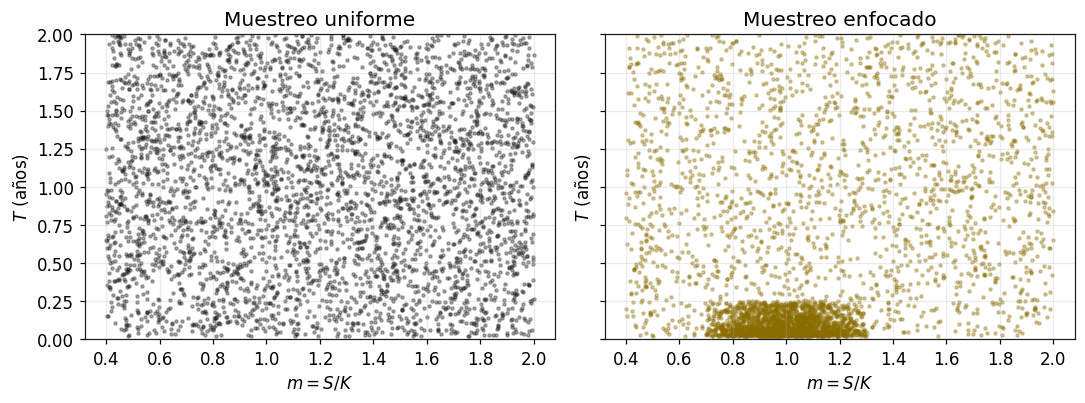

In [4]:
rng = np.random.default_rng(0)
unif = UniformSampler(hdom).sample(4000, rng=rng)
foc = FocusedSampler(hdom).sample(4000, rng=rng)
mi, ti = hdom.input_names.index("moneyness"), hdom.input_names.index("maturity")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True, sharey=True)
ax[0].scatter(unif[:, mi], unif[:, ti], s=4, color=UNIBLACK, alpha=0.35); ax[0].set_title("Muestreo uniforme")
ax[1].scatter(foc[:, mi], foc[:, ti], s=4, color=GOLD, alpha=0.35); ax[1].set_title("Muestreo enfocado")
for a in ax:
    a.set_xlabel("$m = S/K$"); a.set_ylabel("$T$ (años)"); a.set_ylim(0, 2.0)
plt.tight_layout(); plt.show()

---

## 4. Entrenamiento de un surrogate a escala reducida

Para ilustrar el ciclo completo entrenamos en vivo un MLP pequeño sobre Black-Scholes, generamos datos con el solver, entrenamos con `Trainer` y recuperamos la Delta por autograd. En el trabajo la arquitectura es un MLP de 4 capas y 128 unidades con Swish, Adam con $\text{lr}=10^{-3}$ y 100 épocas, entrenado sobre decenas de millones de puntos en GPU. Aquí reducimos tamaño y épocas para que corra en CPU en segundos.

La selección de checkpoint es siempre por menor $\text{MAE}(C/K)$ en validación, igual que en el proyecto, incluso cuando la pérdida incluye Delta, para que las comparaciones sean limpias.

Las dos celdas siguientes entrenan el surrogate de demostración y contrastan su Delta por autograd con la Delta verdadera del solver.

train: (16000, 4) | val: (4000, 4) | con Delta: True


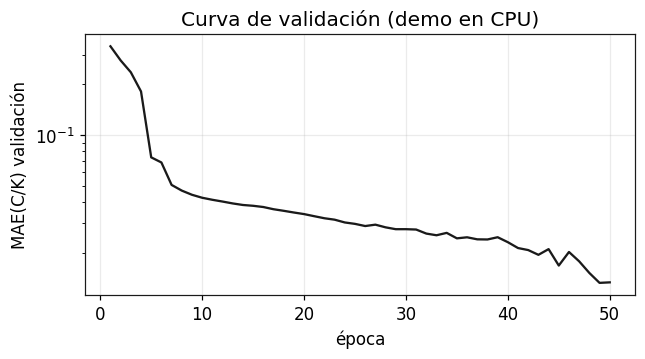

Mejor MAE(C/K) validación: 0.01324


In [5]:
gen = DatasetGenerator(solver=bs, domain=bsdom, sampler=UniformSampler(bsdom),
                       model_family="black_scholes", include_delta=True)
train_ds = gen.generate(16000, seed=1)
val_ds = gen.generate(4000, seed=2)
print("train:", tuple(train_ds.features.shape), "| val:", tuple(val_ds.features.shape),
      "| con Delta:", train_ds.deltas is not None)

model = MLP(input_dim=train_ds.features.shape[1], hidden_width=96, hidden_layers=4, activation="swish")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(
    model=model, loss_fn=PriceLoss(), optimizer=optimizer,
    train_loader=DataLoader(train_ds, batch_size=2048, shuffle=True),
    validation_loader=DataLoader(val_ds, batch_size=2048), device="cpu",
)
history = trainer.fit(epochs=50)
trainer.load_best()

val_mae = [h["validation_price_mae"] for h in history]
plt.figure(figsize=(6, 3.4))
plt.plot(range(1, len(val_mae) + 1), val_mae, color=UNIBLACK)
plt.yscale("log"); plt.xlabel("época"); plt.ylabel("MAE(C/K) validación")
plt.title("Curva de validación (demo en CPU)"); plt.tight_layout(); plt.show()
print("Mejor MAE(C/K) validación:", round(min(val_mae), 5))

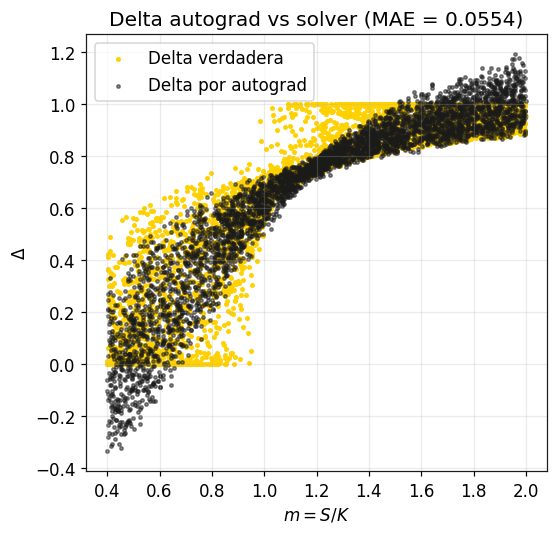

La Delta sale de derivar la red, sin un segundo modelo ni diferencias finitas.


In [6]:
# Delta por autograd frente a la Delta verdadera del solver.
pred_price, pred_delta = surrogate_price_and_delta(model, val_ds.features, moneyness_range=(0.4, 2.0))
pred_delta = pred_delta.detach().numpy().ravel()
true_delta = val_ds.deltas.numpy().ravel()
true_m = val_ds.raw_inputs.numpy()[:, 0]

mae_delta = np.mean(np.abs(pred_delta - true_delta))
plt.figure(figsize=(5.2, 5))
order = np.argsort(true_m)
plt.scatter(true_m, true_delta, s=5, color=UNIYELLOW, label="Delta verdadera")
plt.scatter(true_m, pred_delta, s=5, color=UNIBLACK, alpha=0.5, label="Delta por autograd")
plt.xlabel("$m = S/K$"); plt.ylabel("$\\Delta$"); plt.legend()
plt.title(f"Delta autograd vs solver (MAE = {mae_delta:.4f})"); plt.tight_layout(); plt.show()
print("La Delta sale de derivar la red, sin un segundo modelo ni diferencias finitas.")

---

## 5. Experimentos

Seis experimentos sostienen el trabajo. Cada uno varía una sola dimensión y mantiene el resto fijo.

| Exp. | Pregunta | Métrica primaria |
|------|----------|------------------|
| E1 | ¿Un error de precio bajo implica un error de IV bajo? | $\text{MAE}(C/K)$ vs $\text{MAE}_{\text{IV}}$ por bin |
| E2 | ¿Qué activación da mejores Greeks? | $\text{MAE}_\Delta$ |
| E3 | ¿Ayuda el muestreo enfocado donde hay curvatura? | $\text{MAE}_{\text{IV}}$ en bins ATM |
| E4 | ¿Cuánto más rápido es el surrogate? | speedup $t_{\text{solver}}/t_{\text{surrogate}}$ |
| E5 | ¿Mejora la Delta entrenar con información diferencial? | $\text{MAE}_\Delta$ |
| E6 | ¿Ayuda más profundidad de red o un scheduler de learning rate? | $\text{MAE}(C/K)$ por bin |

A partir de aquí, los resultados se **evalúan en vivo** sobre el test reducido que se genera en la sección siguiente, usando las **redes reales** del paper y las mismas clases de evaluación del repositorio (`src.experiments`). Cada experimento muestra su tabla por bin y su figura, con el estilo del paper. La única excepción es la ilustración analítica de las derivadas de las activaciones en E2, que explica el mecanismo y no depende de las redes.

### 5.0 Reproducción en vivo: filosofía y advertencia

La segunda mitad del notebook **no lee números pre-calculados**. Carga las catorce redes reales del paper (los `checkpoint.pt` de `results/checkpoints/`) y las evalúa aquí mismo con la misma maquinaria del repositorio: las clases de `src.experiments` que usan los *runners* de cada experimento. La intención es enseñar el **procedimiento completo** —generar datos con el solver, evaluar por bins, medir tiempos y dibujar— sobre las redes de verdad, no solo exhibir un resultado cerrado.

Lo único que cambia respecto al paper es la **escala del conjunto de evaluación**, para que todo corra en CPU en pocos minutos y sin depender de `data/`, que no está versionado.

- **Test del paper.** 125 000 puntos balanceados (5 000 por bin), generados en la estación con GPU.
- **Test de este notebook.** 5 000 puntos (200 por bin), generados al momento con el solver.

> **Importante.** Las tablas y las figuras de esta sección **no son las del paper**. Son una *reproducción a escala reducida calculada en vivo*. Con veinticinco veces menos puntos por bin, los valores numéricos difieren y las figuras **no son idénticas** a las de `docs/latex/assets/`; además el entrenamiento original se hizo en GPU, que no es reproducible bit a bit en CPU. Lo que sí se conserva es el **procedimiento** y los **hallazgos cualitativos**, qué activación gana, dónde ayuda el muestreo enfocado, cuánto acelera el surrogate, etc. Las cifras y figuras definitivas viven en el paper.

Las tres celdas siguientes preparan el terreno. La primera **genera el test**, la segunda **evalúa los catorce surrogates** y la tercera **define las figuras** con el estilo del paper. Cada experimento E1–E6 de más abajo consume esos resultados.

**Paso 1 — Generar el test balanceado.** `make_balanced_test` recorre la rejilla 5×5 (moneyness × vencimiento) y, en cada bin, muestrea puntos uniformes, los etiqueta con el solver verdadero (Black-Scholes o Heston) y descarta los que violan las cotas de no-arbitraje. Devuelve un `OptionDataset` con 200 puntos por bin. Es el mismo muestreo balanceado del paper, con menos puntos y generado en memoria, sin escribir en `data/`.

In [7]:
# === Test balanceado pequeno, generado con el solver (autocontenido) ===
# Reproduce el muestreo balanceado del paper (mismo numero de puntos en cada bin
# de la rejilla 5x5 moneyness x vencimiento), pero a escala reducida. No lee
# data/ (no versionado): genera desde cero con BlackScholesSolver / HestonSolver.
import warnings
warnings.filterwarnings("ignore")  # IntegrationWarning del solver de Heston (Fourier)
from src.datasets.sampler import BalancedBinSampler
from src.datasets.generator import OptionDataset

SAMPLES_PER_BIN = 200          # 200 x 25 bins = 5000 puntos por familia
CKPT = ROOT / "results" / "checkpoints"

def _no_arbitrage_mask(raw, prices, deltas, strike=1.0, tol=1e-7):
    "Cotas de no-arbitraje: max(m - K e^{-rT}, 0) <= C/K <= m, y Delta en [0, 1]."
    m, T, r = raw[:, 0], raw[:, 1], raw[:, 2]
    lower = np.maximum(m - strike * np.exp(-r * T), 0.0)
    ok = np.isfinite(prices) & (prices >= lower - tol) & (prices <= m + tol)
    if deltas is not None:
        ok &= np.isfinite(deltas) & (deltas >= -tol) & (deltas <= 1.0 + tol)
    return ok

def make_balanced_test(domain, solver, family, samples_per_bin, seed):
    "Genera un OptionDataset balanceado por bins, etiquetado con el solver verdadero."
    sampler = BalancedBinSampler(domain, samples_per_bin=samples_per_bin)
    rng = np.random.default_rng(seed)
    raws, prices, deltas, bins = [], [], [], []
    for bin_id, _, _, m_bounds, t_bounds in sampler.iter_bins():
        kept, rr, pp, dd = 0, [], [], []
        while kept < samples_per_bin:
            raw = sampler.sample_bin(m_bounds, t_bounds, samples_per_bin, rng)
            if family == "heston":
                p, d = solver.call_price_and_delta(
                    spot=raw[:, 0], strike=1.0, maturity=raw[:, 1], rate=raw[:, 2],
                    v0=raw[:, 3], theta=raw[:, 4], kappa=raw[:, 5], xi=raw[:, 6],
                    rho=raw[:, 7], dividend_yield=domain.dividend_yield)
            else:
                p = solver.call_price(spot=raw[:, 0], strike=1.0, maturity=raw[:, 1],
                                      rate=raw[:, 2], volatility=raw[:, 3], dividend_yield=domain.dividend_yield)
                d = solver.call_delta(spot=raw[:, 0], strike=1.0, maturity=raw[:, 1],
                                      rate=raw[:, 2], volatility=raw[:, 3], dividend_yield=domain.dividend_yield)
            p, d = np.asarray(p, float), np.asarray(d, float)
            mask = _no_arbitrage_mask(raw, p, d)
            rr.append(raw[mask]); pp.append(p[mask]); dd.append(d[mask]); kept += int(mask.sum())
        rr = np.concatenate(rr)[:samples_per_bin]
        pp = np.concatenate(pp)[:samples_per_bin]
        dd = np.concatenate(dd)[:samples_per_bin]
        raws.append(rr); prices.append(pp); deltas.append(dd)
        bins.append(np.full(samples_per_bin, bin_id, np.int64))
    raw = np.concatenate(raws); pr = np.concatenate(prices)
    dl = np.concatenate(deltas); bid = np.concatenate(bins)
    dataset = OptionDataset(
        features=torch.tensor(domain.normalize(raw), dtype=torch.float32),
        prices=torch.tensor(pr, dtype=torch.float32).reshape(-1, 1),
        deltas=torch.tensor(dl, dtype=torch.float32).reshape(-1, 1),
        raw_inputs=torch.tensor(raw, dtype=torch.float32),
        input_names=tuple(domain.input_names))
    return dataset, bid

import time as _t; _t0 = _t.time()
bs_test, bs_bins = make_balanced_test(bsdom, bs, "black_scholes", SAMPLES_PER_BIN, seed=47)
heston_test, heston_bins = make_balanced_test(hdom, hes, "heston", SAMPLES_PER_BIN, seed=46)
print(f"Test BS     : {tuple(bs_test.features.shape)}  (con Delta: {bs_test.deltas is not None})")
print(f"Test Heston : {tuple(heston_test.features.shape)}  (con Delta: {heston_test.deltas is not None})")
print(f"Generados con el solver en {_t.time()-_t0:.1f}s, sin leer data/.")

Test BS     : (5000, 4)  (con Delta: True)
Test Heston : (5000, 8)  (con Delta: True)
Generados con el solver en 20.3s, sin leer data/.


**Paso 2 — Evaluar los catorce surrogates.** Cargamos cada `checkpoint.pt` real y lo pasamos por el test con la clase de estudio que le corresponde (`PriceVsIVStudy`, `ActivationStudy`, `SamplingStudy`, …), exactamente las que usan los *runners* del paper. Cada estudio devuelve una tabla por bin. Abajo se imprime un resumen global de los catorce y los veredictos pre-registrados de E3 y E5. Es la parte más lenta —la inversión a volatilidad implícita y el cronometraje del solver dominan—, del orden de un par de minutos en CPU.

In [8]:
# === Evaluacion de los 14 surrogates reales con la metodologia del repo ===
# Cada experimento usa SU clase de src.experiments (igual que los runners del paper),
# pero sobre el test reducido. Cargamos los checkpoints reales de results/checkpoints/.
import time as _t
from src.utils import load_mlp_checkpoint
from src.evaluation import BinEvaluator, BinPartition
from src.evaluation.timing import TimingBenchmark
from src.experiments import (PriceVsIVStudy, ActivationStudy, SamplingStudy,
                             EfficiencyStudy, DMLStudy, ArchitectureStudy, SurrogateInput)

def make_input(name, dataset, bin_id, pricer, labels=None, label_fn=None):
    "Carga un checkpoint real y lo envuelve como SurrogateInput con su evaluador por bins."
    model, cfg = load_mlp_checkpoint(CKPT / name)
    evaluator = BinEvaluator(partition=BinPartition.default(), pricer=pricer, device="cpu", batch_size=32768)
    lab = label_fn(cfg) if label_fn else (labels or {})
    return SurrogateInput(surrogate_id=name, model=model, dataset=dataset, evaluator=evaluator, bin_id=bin_id, labels=lab)

_t0 = _t.time()
# E1 — precio vs IV (baselines BS-3 y H-3)
e1_df = pd.DataFrame(PriceVsIVStudy(inputs=(
    make_input("BS-3", bs_test, bs_bins, bs),
    make_input("H-3", heston_test, heston_bins, hes))).run().table)

# E2 — activaciones (4 redes por familia); etiqueta 'activation' desde config.json
_act = lambda cfg: {"activation": str(cfg.get("activation", ""))}
e2_bs_df = pd.DataFrame(ActivationStudy(inputs=tuple(
    make_input(c, bs_test, bs_bins, bs, label_fn=_act) for c in ("BS-1", "BS-2", "BS-3", "BS-4")),
    family_label="Black-Scholes").run().table)
e2_h_df = pd.DataFrame(ActivationStudy(inputs=tuple(
    make_input(c, heston_test, heston_bins, hes, label_fn=_act) for c in ("H-1", "H-2", "H-3", "H-4")),
    family_label="Heston").run().table)

# E3 — muestreo uniforme (H-3) vs enfocado (H-5); mismo test, distinto entrenamiento
_e3 = SamplingStudy(inputs=(
    make_input("H-3", heston_test, heston_bins, hes, labels={"sampler": "uniform"}),
    make_input("H-5", heston_test, heston_bins, hes, labels={"sampler": "focused"}))).run()
e3_df, e3_verdict = pd.DataFrame(_e3.table), _e3.verdict

# E5 — differential ML (precio vs precio+Delta a igual datos, mas baseline grande)
_role = lambda r: (lambda cfg: {"role": r, "loss": str(cfg.get("loss", ""))})
_e5 = DMLStudy(inputs=(
    make_input("H-3-small", heston_test, heston_bins, hes, label_fn=_role("small_price")),
    make_input("H-6-small", heston_test, heston_bins, hes, label_fn=_role("small_dml")),
    make_input("H-3", heston_test, heston_bins, hes, label_fn=_role("baseline_large")))).run()
e5_df, e5_verdict = pd.DataFrame(_e5.table), _e5.verdict

# E6 — profundidad de red y scheduler; etiqueta 'architecture' (capas x ancho [+scheduler])
def _arch_label(role):
    def f(cfg):
        L, W = int(cfg.get("hidden_layers", 0)), int(cfg.get("hidden_width", 0))
        s = str(cfg.get("scheduler", "none")).lower()
        return {"role": role, "architecture": f"{L}x{W}" + (f"+{s}" if s != "none" else "")}
    return f
e6_df = pd.DataFrame(ArchitectureStudy(inputs=(
    make_input("H-3", heston_test, heston_bins, hes, label_fn=_arch_label("baseline")),
    make_input("H-7-shallow", heston_test, heston_bins, hes, label_fn=_arch_label("shallow")),
    make_input("H-8-deep", heston_test, heston_bins, hes, label_fn=_arch_label("deep")),
    make_input("H-9-lr-schedule", heston_test, heston_bins, hes, label_fn=_arch_label("lr_schedule")))).run().table)

# E4 — eficiencia (timing solver vs surrogate, solo CPU). solver_workers=1 evita el
# fallo de multiprocessing 'spawn' dentro de un notebook.
_npts = heston_test.features.shape[0]
_batches = tuple(b for b in (100, 1000, 5000) if b <= _npts)
_bench = TimingBenchmark(pricer=hes, raw_inputs=heston_test.raw_inputs.numpy(),
                         features=heston_test.features.numpy(), input_names=tuple(heston_test.input_names),
                         batch_sizes=_batches, n_warmups=1, n_repetitions=3, solver_workers=1)
e4_df = pd.DataFrame(EfficiencyStudy(benchmark=_bench, surrogate=load_mlp_checkpoint(CKPT / "H-3")[0],
                                     surrogate_id="H-3", devices=("cpu",)).run().table)

# Resumen global de los 14 (una pasada por bin sin IV, para una vista de pajaro rapida)
_ALL = [(n, bs_test, bs_bins, bs) for n in ("BS-1", "BS-2", "BS-3", "BS-4")] + \
       [(n, heston_test, heston_bins, hes) for n in ("H-1", "H-2", "H-3", "H-4", "H-5",
                                                      "H-3-small", "H-6-small", "H-7-shallow", "H-8-deep", "H-9-lr-schedule")]
_rows = []
for _name, _ds, _bid, _pricer in _ALL:
    _m, _ = load_mlp_checkpoint(CKPT / _name)
    _ev = BinEvaluator(partition=BinPartition.default(), pricer=_pricer, device="cpu", batch_size=32768)
    _rep = _ev.evaluate(surrogate=_m, dataset=_ds, bin_id=_bid, compute_iv=False, surrogate_id=_name)
    _rows.append({"surrogate": _name, "familia": "BS" if _name.startswith("BS") else "Heston",
                  "MAE(C/K)": np.nanmean(_rep.price["mean"]), "MAE_Delta": np.nanmean(_rep.delta["mean"])})
resumen14 = pd.DataFrame(_rows).set_index("surrogate")

print(f"14 surrogates evaluados en {_t.time()-_t0:.0f}s  |  veredictos: E3={e3_verdict}, E5={e5_verdict}\n")
print("Resumen global (MAE medio por bin sobre el test reducido):")
print(resumen14.to_string(formatters={"MAE(C/K)": lambda x: f"{x:.3e}", "MAE_Delta": lambda x: f"{x:.3e}"}))

[+00m00.00s] benchmark start: batch_sizes=[100, 1000, 5000], devices=['cpu'], warmups=1, repetitions=3, solver_workers=1
[+00m00.00s] === batch_size=100 ===
[+00m02.47s]   solver done. median=0.6135s, throughput=163.0 opt/s
[+00m02.48s]   surrogate[cpu] done. median=1.7208e-04s, speedup=x3565.0
[+00m02.48s] === batch_size=1000 ===
[+00m20.16s]   solver done. median=4.4006s, throughput=227.2 opt/s
[+00m20.20s]   surrogate[cpu] done. median=1.6066e-03s, speedup=x2739.1
[+00m20.21s] === batch_size=5000 ===
[+01m22.72s]   solver done. median=15.6093s, throughput=320.3 opt/s
[+01m22.80s]   surrogate[cpu] done. median=5.7900e-03s, speedup=x2695.9
[+01m22.80s] benchmark complete.
14 surrogates evaluados en 99s  |  veredictos: E3=positivo_fuerte, E5=positivo_fuerte

Resumen global (MAE medio por bin sobre el test reducido):
                familia  MAE(C/K) MAE_Delta
surrogate                                  
BS-1                 BS 1.950e-03 2.678e-02
BS-2                 BS 4.317e-03 2.284e

**Paso 3 — Figuras con el estilo del paper.** Reutilizamos `paper_style`, el módulo del repositorio con la paleta, la tipografía y los mapas de color del documento, y definimos una función por figura. Todavía no se dibuja nada; cada experimento llamará a la suya con sus datos reducidos. Así las figuras salen con el mismo aspecto que las del paper aunque los datos que las alimentan sean los del test pequeño.

In [9]:
# === Utilidades de figura: replican el estilo exacto del paper (paper_style) ===
# Importamos la identidad visual del documento y definimos una funcion por figura.
# Las alimentaremos con los DataFrames reducidos de las celdas E1-E6.
import sys as _sys
_sys.path.insert(0, str(ROOT / "scripts" / "figures"))
import paper_style as ps
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator, PercentFormatter

ps.apply_paper_style()
_INK = ps.PALETTE["uniblack"]

def _fmt_exp(v):
    if not np.isfinite(v):
        return ""
    if v == 0:
        return "0"
    e = int(np.floor(np.log10(abs(v))))
    return f"{v/10**e:.2f}e{e}"

def fig_e1_scatter(frame):
    "Scatter MAE_IV vs MAE(C/K) por bin; color = Vega proxy; circulo H-3, triangulo BS-3."
    vcmap = mcolors.LinearSegmentedColormap.from_list("vega", ["#1A1A1A", "#6E5600", "#B89200", "#FFD100"])
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    xl = np.array([8e-5, 1.2e-2])
    for k, lab in [(1, "1:1"), (10, r"$\times 10$"), (100, r"$\times 100$"), (1000, r"$\times 1000$")]:
        ax.plot(xl, k * xl, ls="--", lw=0.8, color="#BBBBBB", zorder=1)
        ax.text(xl[1], k * xl[1], f" {lab}", fontsize=8, color="#8A8A8A", va="center")
    norm = mcolors.LogNorm(vmin=np.nanmin(frame["vega_proxy_mean"]), vmax=np.nanmax(frame["vega_proxy_mean"]))
    sc = None
    for surr, mk in {"H-3": "o", "BS-3": "^"}.items():
        s = frame[frame.surrogate_id == surr]
        sc = ax.scatter(s["price_mae_mean"], s["iv_mae_mean"], c=s["vega_proxy_mean"], cmap=vcmap, norm=norm,
                        marker=mk, s=85, edgecolors=_INK, linewidths=0.7, label=surr, zorder=3)
    for surr, off in {"H-3": (-2, 10), "BS-3": (8, -14)}.items():
        s = frame[frame.surrogate_id == surr]
        w = s.loc[s["iv_to_price_ratio"].idxmax()]
        ax.annotate(f'{surr}: {w["bin_label"].replace("_", " ")}', (w["price_mae_mean"], w["iv_mae_mean"]),
                    textcoords="offset points", xytext=off, fontsize=8, color=_INK)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"MAE$(C/K)$"); ax.set_ylabel(r"MAE$_{\mathrm{IV}}$")
    ax.grid(True, which="both", ls=":", lw=0.4, color="#E2E2E2")
    ax.legend(title="Surrogate", fontsize=9, loc="lower right")
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04); cb.set_label("Vega proxy media del bin", fontsize=9)
    plt.tight_layout(); plt.show()

def fig_heatmap(frame, surrogate, column, metric_label, log_color=True):
    "Heatmap 5x5 (moneyness x vencimiento) de una metrica por bin, paleta Hesperides."
    f = frame[frame.surrogate_id == surrogate]
    grid = np.full((5, 5), np.nan)
    for _, r in f.iterrows():
        grid[int(r.maturity_idx), int(r.moneyness_idx)] = r[column]
    fin = grid[np.isfinite(grid)]
    norm = mcolors.LogNorm(fin.min(), fin.max()) if log_color else mcolors.Normalize(fin.min(), fin.max())
    cmap = ps.heatmap_cmap().copy(); cmap.set_bad("#dddddd")
    fig, ax = plt.subplots(figsize=(5.4, 4.8)); ax.grid(False)
    im = ax.imshow(np.ma.masked_invalid(grid), cmap=cmap, norm=norm, aspect="auto", origin="upper")
    ax.set_xticks(range(5)); ax.set_xticklabels(ps.MONEYNESS_LABELS, fontsize=8.5)
    ax.set_yticks(range(5)); ax.set_yticklabels(ps.MATURITY_LABELS, fontsize=8.5)
    ax.set_xlabel("Moneyness $m = S/K$", fontsize=9.5); ax.set_ylabel("Vencimiento $T$", fontsize=9.5)
    ax.set_title(f"{surrogate} — {metric_label} (media por bin)", fontsize=10.5)
    for i in range(5):
        for j in range(5):
            v = grid[i, j]
            if not np.isfinite(v):
                continue
            rgba = cmap(norm(v)); lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            ax.text(j, i, _fmt_exp(v), ha="center", va="center", fontsize=8.5, color="white" if lum < 0.5 else _INK)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=9)
    plt.tight_layout(); plt.show()

def fig_e2_tradeoff(df_bs, df_h):
    "Plano precio-Delta por activacion, una faceta por familia (abajo-izq = mejor)."
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.5))
    for ax, (fam, df) in zip(axes, (("Black-Scholes", df_bs), ("Heston", df_h))):
        agg = df.groupby("activation").agg(price=("price_mae_mean", "mean"), delta=("delta_mae_mean", "mean"))
        for act, row in agg.iterrows():
            ax.scatter(row.price, row.delta, s=150, color=ps.ACT_COLOR[act], edgecolors=_INK, linewidths=0.9, zorder=3)
            ax.annotate(ps.ACT_LABEL[act], (row.price, row.delta), textcoords="offset points", xytext=(9, 4), fontsize=10, color=_INK)
        ax.set_title(fam, fontsize=12, fontweight="bold", pad=8)
        ax.set_xlabel(r"MAE$(C/K)$  (error de precio)", fontsize=10.5)
        ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0)); ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        ax.xaxis.set_major_locator(MaxNLocator(5)); ax.yaxis.set_major_locator(MaxNLocator(6))
        xm, xM, ym, yM = agg.price.min(), agg.price.max(), agg.delta.min(), agg.delta.max()
        ax.set_xlim(xm - 0.20 * (xM - xm), xM + 0.32 * (xM - xm)); ax.set_ylim(ym - 0.14 * (yM - ym), yM + 0.20 * (yM - ym))
    axes[0].set_ylabel(r"MAE$_\Delta$  (error de Delta)", fontsize=10.5)
    plt.tight_layout(); plt.show()

def fig_e3_diff(frame, column, metric_label):
    "Heatmap divergente de mejora relativa de H-5 (enfocado) frente a H-3 (uniforme)."
    u = frame[frame.surrogate_id == "H-3"].set_index("bin_label")
    f = frame[frame.surrogate_id == "H-5"].set_index("bin_label")
    grid = np.full((5, 5), np.nan)
    for lab, row in u.iterrows():
        grid[int(row.maturity_idx), int(row.moneyness_idx)] = (row[column] - f.loc[lab, column]) / row[column]
    vmax = np.nanmax(np.abs(grid))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax); cmap = ps.diverging_cmap()
    fig, ax = plt.subplots(figsize=(5.8, 5.0)); ax.grid(False)
    im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto", origin="upper")
    ax.set_xticks(range(5)); ax.set_xticklabels(ps.MONEYNESS_LABELS, fontsize=8.5)
    ax.set_yticks(range(5)); ax.set_yticklabels(ps.MATURITY_LABELS, fontsize=8.5)
    ax.set_xlabel("Moneyness $m = S/K$", fontsize=9.5); ax.set_ylabel("Vencimiento $T$", fontsize=9.5)
    ax.set_title(f"H-5 frente a H-3 — mejora relativa de {metric_label}", fontsize=10.5)
    for i in range(5):
        for j in range(5):
            v = grid[i, j]
            if not np.isfinite(v):
                continue
            rgba = cmap(norm(v)); lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            ax.text(j, i, f"{v*100:+.0f}%", ha="center", va="center", fontsize=8.5, color="white" if lum < 0.5 else _INK)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format=PercentFormatter(xmax=1.0, decimals=0)); cb.ax.tick_params(labelsize=8)
    plt.tight_layout(); plt.show()

def fig_e4_timing(df):
    "Tiempo (solver vs surrogate) y speedup frente al tamano de lote, en CPU."
    cpu = df[df.device == "cpu"].sort_values("batch_size"); b = cpu.batch_size.to_numpy()
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.6, 4.4))
    def curve(ax, x, med, p25, p75, color, label):
        ax.plot(x, med, "o-", color=color, lw=1.8, ms=6, label=label, zorder=3, markeredgecolor=_INK, markeredgewidth=0.6)
        ax.fill_between(x, p25, p75, color=color, alpha=0.18, zorder=1)
    curve(axL, b, cpu.solver_median_s, cpu.solver_p25_s, cpu.solver_p75_s, ps.PALETTE["uniblack"], "Solver (Heston)")
    curve(axL, b, cpu.surrogate_median_s, cpu.surrogate_p25_s, cpu.surrogate_p75_s, ps.PALETTE["gold"], "Surrogate (CPU)")
    axL.set_xscale("log"); axL.set_yscale("log"); axL.set_xlabel("Tamaño de lote", fontsize=10.5)
    axL.set_ylabel("Tiempo (s)", fontsize=10.5); axL.set_title("Tiempo de evaluación", fontsize=11); axL.legend(fontsize=8.5, loc="upper left")
    axR.plot(b, cpu.speedup_median, "o-", color=ps.PALETTE["gold"], lw=1.8, ms=6, label="CPU", markeredgecolor=_INK, markeredgewidth=0.6)
    axR.set_xscale("log"); axR.set_yscale("log"); axR.set_xlabel("Tamaño de lote", fontsize=10.5)
    axR.set_ylabel(r"Speedup ($t_{\mathrm{solver}}/t_{\mathrm{surrogate}}$)", fontsize=10.5)
    axR.set_title("Aceleración frente al solver", fontsize=11); axR.legend(fontsize=8.5, loc="upper left")
    plt.tight_layout(); plt.show()

def fig_e5_tradeoff(frame):
    "Plano precio-Delta de los tres surrogates de E5 (DML reduce la Delta)."
    agg = frame.groupby("role").agg(price=("price_mae_mean", "mean"), delta=("delta_mae_mean", "mean"))
    pts = [("small_price", "H-3-small (precio, 5M)", ps.PALETTE["orange"], (10, 2)),
           ("small_dml", "H-6-small (precio+$\\Delta$, 5M)", ps.PALETTE["green"], (10, -4)),
           ("baseline_large", "H-3 (precio, 25M)", _INK, (10, 8))]
    fig, ax = plt.subplots(figsize=(6.6, 5.0))
    for role, lab, color, off in pts:
        if role not in agg.index:
            continue
        x, y = agg.loc[role, "price"], agg.loc[role, "delta"]
        ax.scatter(x, y, s=150, color=color, edgecolors=_INK, linewidths=0.9, zorder=3)
        ax.annotate(lab, (x, y), textcoords="offset points", xytext=off, fontsize=9.5, color=_INK, ha="left")
    ax.set_xlabel(r"MAE$(C/K)$  (error de precio)", fontsize=10.5); ax.set_ylabel(r"MAE$_\Delta$  (error de Delta)", fontsize=10.5)
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0)); ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    xm, xM, ym, yM = agg.price.min(), agg.price.max(), agg.delta.min(), agg.delta.max()
    ax.set_xlim(xm - 0.22 * (xM - xm), xM + 0.30 * (xM - xm)); ax.set_ylim(ym - 0.18 * (yM - ym), yM + 0.20 * (yM - ym))
    plt.tight_layout(); plt.show()

def fig_e6_summary(frame):
    "Barras de MAE(C/K) y MAE_Delta por variante de profundidad/scheduler; baseline en dorado."
    agg = (frame.groupby(["surrogate_id", "role"])
           .agg(price=("price_mae_mean", "mean"), delta=("delta_mae_mean", "mean"))
           .reset_index().sort_values("price"))
    colors = [ps.PALETTE["gold"] if r == "baseline" else _INK for r in agg.role]; xp = range(len(agg))
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.9))
    for a, col, title in ((ax[0], "price", r"MAE$(C/K)$ medio por bin"), (ax[1], "delta", r"MAE$_\Delta$ medio por bin")):
        a.bar(xp, agg[col], color=colors, edgecolor=_INK, linewidth=0.6); a.set_title(title, fontsize=11, fontweight="bold", pad=8)
        a.set_xticks(list(xp)); a.set_xticklabels(agg.surrogate_id, rotation=20, ha="right", fontsize=8.5)
        a.ticklabel_format(style="sci", axis="y", scilimits=(0, 0)); a.grid(axis="x", visible=False)
    plt.tight_layout(); plt.show()

print("Funciones de figura listas (estilo paper).")

Funciones de figura listas (estilo paper).


### E1 — Precio frente a volatilidad implícita

Un $\text{MAE}(C/K)$ bajo no implica un $\text{MAE}_{\text{IV}}$ bajo. En las regiones de Vega baja (alas profundas, vencimientos cortos) un error de precio diminuto se amplifica al invertir a IV, porque $\delta\sigma \approx \delta C / \mathcal{V}$. Lo vemos por bin con las redes reales **BS-3** y **H-3** evaluadas sobre el test reducido, y en el scatter por bin que cruza ambos errores.

              price_mae  iv_mae  iv_fail
surrogate_id                            
BS-3             0.0018  0.2034    0.246
H-3              0.0013  0.1675    0.145


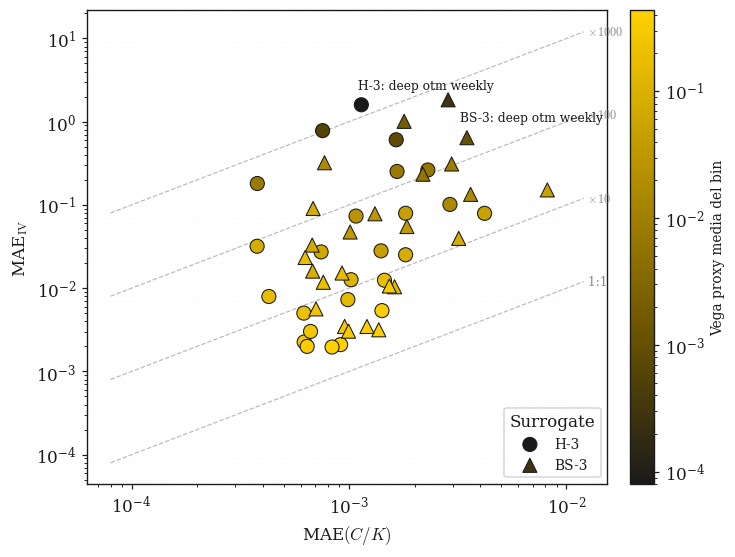

In [10]:
# E1: resumen por surrogate + scatter MAE_IV vs MAE(C/K) por bin (redes reales BS-3 y H-3).
resumen_e1 = e1_df.groupby("surrogate_id").agg(
    price_mae=("price_mae_mean", "mean"),
    iv_mae=("iv_mae_mean", "mean"),
    iv_fail=("iv_failure_rate", "mean"),
).round(4)
print(resumen_e1)
# Cada punto es un bin: el MAE(C/K) puede ser diminuto y la IV dispararse (Vega baja).
fig_e1_scatter(e1_df)

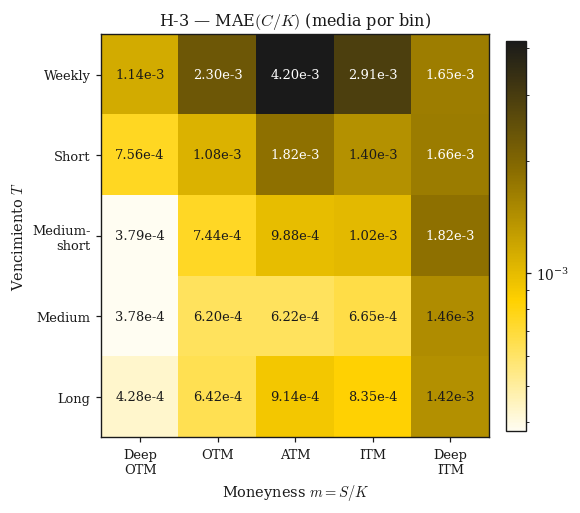

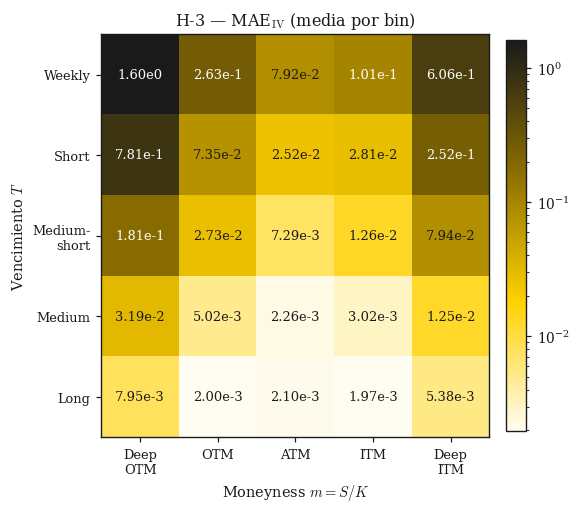

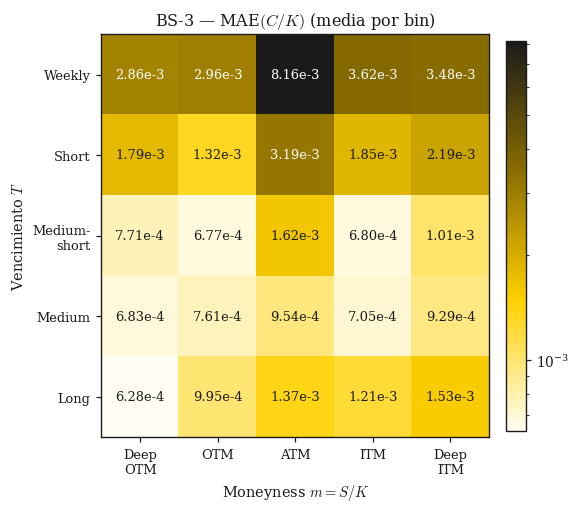

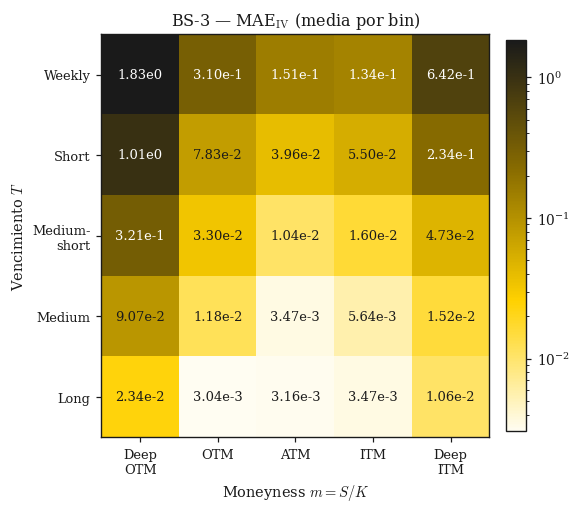

In [11]:
# Mapas por bin (media): el precio es casi plano; la IV se dispara en las alas de Vega baja.
fig_heatmap(e1_df, "H-3", "price_mae_mean", r"MAE$(C/K)$")
fig_heatmap(e1_df, "H-3", "iv_mae_mean", r"MAE$_{\mathrm{IV}}$")
fig_heatmap(e1_df, "BS-3", "price_mae_mean", r"MAE$(C/K)$")
fig_heatmap(e1_df, "BS-3", "iv_mae_mean", r"MAE$_{\mathrm{IV}}$")

### E2 — Activaciones y calidad de la Delta

La derivada de ReLU es discontinua en cero, y eso se propaga a la Delta calculada por autograd. Las activaciones suaves (Swish, Softplus, tanh) no tienen ese problema. Primero dibujamos las cuatro activaciones y sus derivadas, una ilustración analítica del mecanismo que no depende de las redes. Después medimos el error medio de Delta por activación evaluando las redes reales (BS-1…4 y H-1…4) sobre el test reducido, así que las cifras son menores en muestra que las del paper aunque el orden entre activaciones se mantiene.

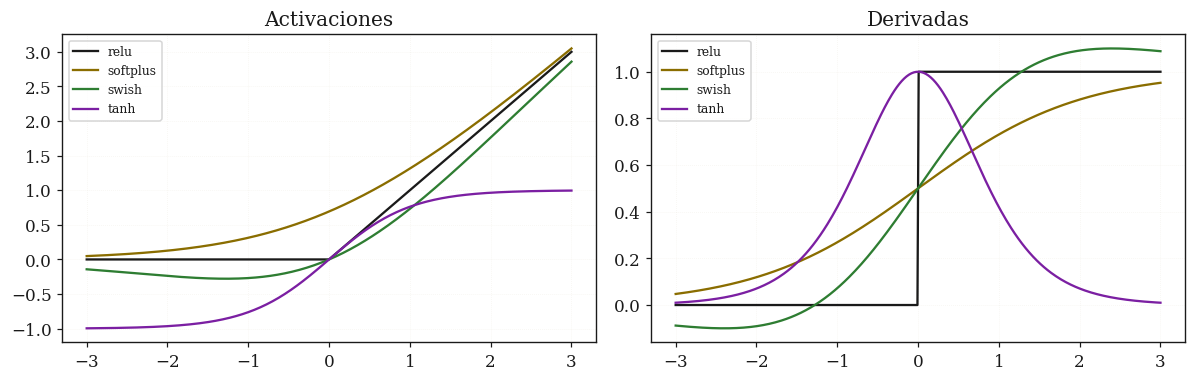

In [12]:
xs = torch.linspace(-3, 3, 400).reshape(-1, 1).requires_grad_(True)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
colors = {"relu": UNIBLACK, "softplus": GOLD, "swish": "#2E7D32", "tanh": "#7B1FA2"}
for name in ["relu", "softplus", "swish", "tanh"]:
    act = ACTIVATIONS[name]()
    y = act(xs)
    g, = torch.autograd.grad(y.sum(), xs, create_graph=False, retain_graph=True)
    ax[0].plot(xs.detach().ravel(), y.detach().ravel(), color=colors[name], label=name)
    ax[1].plot(xs.detach().ravel(), g.detach().ravel(), color=colors[name], label=name)
ax[0].set_title("Activaciones"); ax[1].set_title("Derivadas")
for a in ax: a.legend(fontsize=8)
plt.tight_layout(); plt.show()

                  familia  price_mae  delta_mae
activation                                     
relu        Black-Scholes     0.0020     0.0268
softplus    Black-Scholes     0.0043     0.0228
swish       Black-Scholes     0.0018     0.0176
tanh        Black-Scholes     0.0028     0.0252
relu               Heston     0.0013     0.0161
softplus           Heston     0.0026     0.0151
swish              Heston     0.0013     0.0108
tanh               Heston     0.0019     0.0164


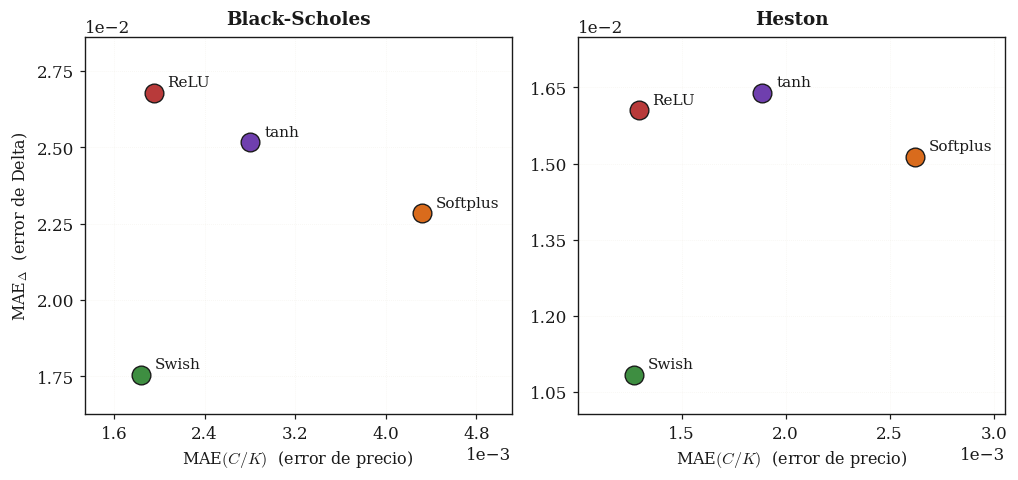

In [13]:
# Error medio por activación (media sobre los 25 bins), redes reales por familia.
def _e2_resumen(df, fam):
    agg = df.groupby("activation").agg(price_mae=("price_mae_mean", "mean"),
                                       delta_mae=("delta_mae_mean", "mean"))
    agg.insert(0, "familia", fam)
    return agg
resumen_e2 = pd.concat([_e2_resumen(e2_bs_df, "Black-Scholes"),
                        _e2_resumen(e2_h_df, "Heston")]).round(4)
print(resumen_e2)
# Plano precio-Delta: Swish queda abajo-izquierda (mejor en ambas), ReLU degrada la Delta.
fig_e2_tradeoff(e2_bs_df, e2_h_df)

### E3 — Muestreo uniforme frente a enfocado

H-3 entrena con muestreo uniforme y H-5 con muestreo enfocado, pero **ambos se evalúan sobre el mismo test reducido**, para medir limpiamente dónde gana y dónde pierde el enfoque local. El control de precio acompaña a la métrica de IV porque no sufre la amplificación de Vega. El veredicto sigue la regla pre-registrada del estudio; el heatmap divergente compara bin a bin y, al ser sobre el test pequeño, los porcentajes difieren de los del paper aunque el patrón es el mismo.

                      price_mae  iv_mae
surrogate_id sampler                   
H-3          uniform     0.0013  0.1675
H-5          focused     0.0009  0.1357

MAE(IV) en bins críticos ATM:
 surrogate_id
H-3    0.0372
H-5    0.0079
Name: iv_mae_mean, dtype: float64

Veredicto pre-registrado: positivo_fuerte


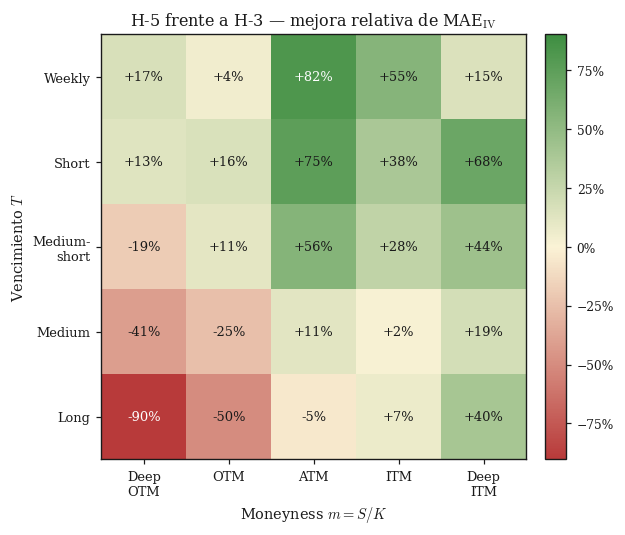

In [14]:
e3_resumen = e3_df.groupby(["surrogate_id", "sampler"]).agg(
    price_mae=("price_mae_mean", "mean"),
    iv_mae=("iv_mae_mean", "mean"),
).round(4)
print(e3_resumen)
# Bins críticos (ATM + corto plazo), donde el muestreo enfocado debería ayudar más.
crit = e3_df[e3_df["is_critical"]].groupby("surrogate_id")["iv_mae_mean"].mean().round(4)
print("\nMAE(IV) en bins críticos ATM:\n", crit)
print("\nVeredicto pre-registrado:", e3_verdict)
# Verde = el enfocado reduce el error de IV; rojo = lo empeora.
fig_e3_diff(e3_df, "iv_mae_mean", r"MAE$_{\mathrm{IV}}$")

### E4 — Eficiencia computacional

El surrogate sustituye al solver de Heston, mucho más caro, y la ganancia es de órdenes de magnitud. Aquí los tiempos se miden **en vivo en esta máquina** (solo CPU): la mediana de varias repeticiones del solver de Heston frente al surrogate H-3, para distintos tamaños de lote. En el paper la comparación incluye además la GPU.

device  batch_size  solver_median_s  surrogate_median_s  speedup_median
   cpu         100         0.613486            0.000172     3565.040918
   cpu        1000         4.400584            0.001607     2739.093932
   cpu        5000        15.609255            0.005790     2695.879437


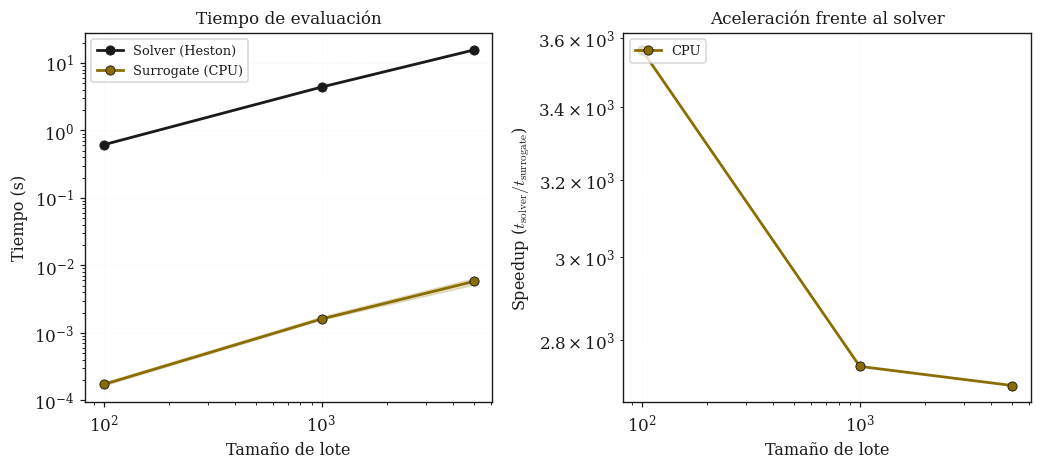

In [15]:
print(e4_df[["device", "batch_size", "solver_median_s", "surrogate_median_s", "speedup_median"]].to_string(index=False))
# El solver crece con el lote; el surrogate apenas. El speedup es de miles de veces.
fig_e4_timing(e4_df)

### E5 — Differential machine learning

El differential ML añade la Delta al objetivo, $\mathcal{L} = \text{MAE}(C/K) + \lambda\,\text{MAE}(\Delta)$, con la Delta obtenida por autograd y `create_graph=True`. Comparamos tres surrogates, H-3-small (precio, 5M), H-6-small (diferencial, 5M, mismos datos y semilla) y H-3 (precio, baseline grande 25M). Los tamaños 5M y 25M son de su **entrenamiento** original y no cambian; aquí los tres se evalúan sobre el mismo test reducido y el veredicto sigue la regla pre-registrada.

                                          price_mae  delta_mae
surrogate_id role           loss                              
H-3          baseline_large price            0.0013     0.0108
H-3-small    small_price    price            0.0025     0.0169
H-6-small    small_dml      differential     0.0015     0.0069

Veredicto pre-registrado: positivo_fuerte


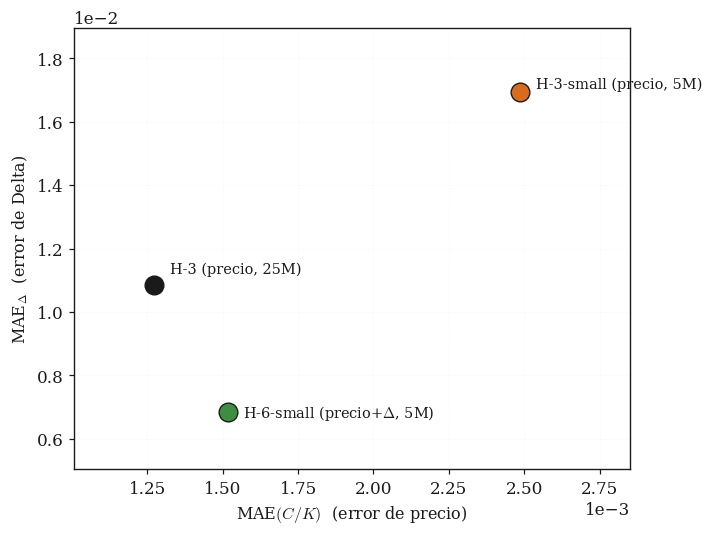

In [16]:
e5_resumen = e5_df.groupby(["surrogate_id", "role", "loss"]).agg(
    price_mae=("price_mae_mean", "mean"),
    delta_mae=("delta_mae_mean", "mean"),
).round(4)
print(e5_resumen)
print("\nVeredicto pre-registrado:", e5_verdict)
# A igual datos y semilla, el DML (verde) baja la Delta sin pagar apenas en precio.
fig_e5_tradeoff(e5_df)

### E6 — Profundidad de la red y scheduler de learning rate

E6 acota dos vías de mejora sobre el baseline H-3 que no formaban parte de E1–E5, ampliar la profundidad de la red o introducir un scheduler de learning rate cuando la validación se estanca. Las cuatro variantes comparten dataset de **entrenamiento** (25M), semilla del entrenador (203), batch, activación Swish y pérdida de precio, de modo que la única diferencia es la profundidad (H-7-shallow 2×128, H-3 4×128, H-8-deep 6×128) o la presencia del scheduler (H-9-lr-schedule, `ReduceLROnPlateau`). Aquí se evalúan sobre el test reducido; la lectura es observacional, ordenada por reducción del $\text{MAE}(C/K)$ por bin frente al baseline.

   surrogate_id  architecture        role  price_mae  delta_mae  red_precio_%
H-9-lr-schedule 4x128+plateau lr_schedule   0.001139   0.011479          10.6
            H-3         4x128    baseline   0.001274   0.010845           0.0
       H-8-deep         6x128        deep   0.001981   0.011286         -55.5
    H-7-shallow         2x128     shallow   0.003482   0.029711        -173.3


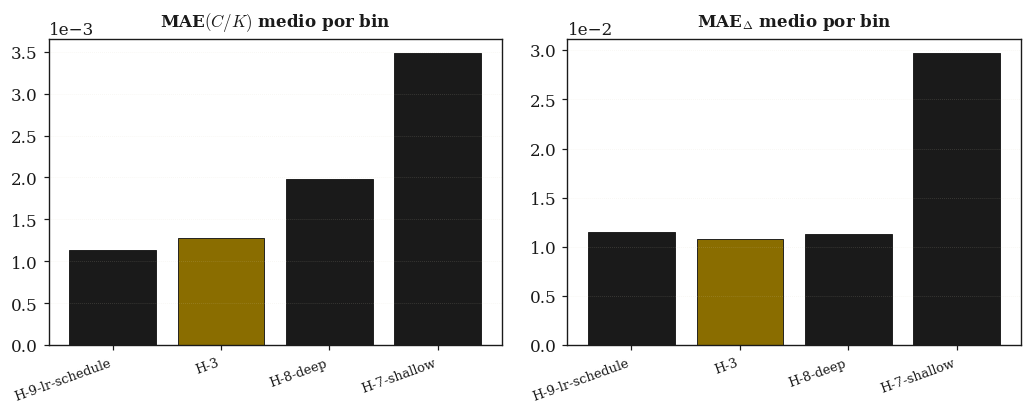

In [17]:
resumen_e6 = e6_df.groupby(["surrogate_id", "architecture", "role"]).agg(
    price_mae=("price_mae_mean", "mean"),
    delta_mae=("delta_mae_mean", "mean"),
).reset_index().sort_values("price_mae")
base = resumen_e6.loc[resumen_e6["role"] == "baseline", "price_mae"].iloc[0]
resumen_e6["red_precio_%"] = (100 * (base - resumen_e6["price_mae"]) / base).round(1)
print(resumen_e6.to_string(index=False))
# Baseline H-3 en dorado. Solo el scheduler (H-9) lo mejora; la profundidad lo empeora.
fig_e6_summary(e6_df)

---

## 6. Discusión y conclusiones

A escala reducida hemos recorrido las mismas piezas que el paper desarrolla a fondo. Las redes con activación suave imitan al solver con un error de precio del orden de $10^{-3}$ y producen Deltas estables por diferenciación automática, lo que las hace útiles no solo para valorar sino para cubrir y calibrar.

Las conclusiones que se sostienen son cuatro. La métrica importa, porque un error de precio pequeño puede esconder un error de volatilidad implícita grande en las regiones de Vega baja. La activación gobierna la calidad de las Greeks, y Swish domina. El muestreo enfocado ayuda donde hay más curvatura sin perder cobertura global. Y entrenar con información diferencial mejora la Delta y la eficiencia muestral, alcanzando con menos datos lo que el baseline grande logra solo en precio.

A esas cuatro se suman dos lecturas de ingeniería sobre el modelo. El surrogate evalúa órdenes de magnitud más rápido que el solver de Heston, lo que justifica sustituirlo en los bucles de calibración y cobertura donde se valora millones de veces. Y sobre el baseline H-3, ampliar la profundidad de la red no ayuda, mientras que un scheduler que reduce el learning rate cuando la validación se estanca aporta una mejora marginal.

El detalle de los catorce surrogates, el régimen de datos completo y las tablas y figuras definitivas están en el paper, que este notebook acompaña pero no sustituye.